# Operator Dynamics in Random Bricklayer Circuits with Pauli chain Propagation and Matrix Product Operator (MPO) propagation

I've written some Julia module,
- `matrix_product_operator_functions.jl`, based on the MPO evolution method and the `ITensors.jl` (and `ITensorMPS.jl`) package for managing tensors,
- `pauli_propagation_functions.jl`, based on the paper “*Pauli Propagation: A Computational Framework for Simulating Quantum Systems*” and the associated package `PauliPropagation.jl`,
- `exact_functions.jl`, which simply calculates the “theoretical,” exact results of a propagation,
- `circuit.jl`, which allows you to initialize different types of circuits, including the MFIM, for the different methods we will need in this notebook.

These module allows me to handle propagation of an observable (in the Heisenberg picture) through a quantum circuit.

The goal of this notebook is to study the time evolution of a local quantum observable and examine how the complexity of these methods scales with the number of qubits.

In [23]:
# using Pkg; Pkg.add("LaTeXStrings"); Pkg.add("PauliPropagation"); Pkg.add("ITensors"); Pkg.add("ITensorMPS")

In [61]:
using LaTeXStrings
using Plots
using LinearAlgebra
import Statistics: mean

# --- Pauli Propagation ---
using PauliPropagation

#include("../src/pauli_propagation_functions.jl")
include("pauli_propagation_functions.jl")
import .pauli_propagation_functions as pp

# --- MPO ---
using ITensors, ITensorMPS

#include("../src/matrix_product_operator_functions.jl")
include("matrix_product_operator_functions.jl")
import .mpo_functions as mpo

# --- Exact method ---

#include("../src/exact_functions.jl")
include("exact_functions.jl")
import .exact_functions as ext

# --- other ---
#include("../src/utils.jl")
include("utils.jl")
import .utils as us

#include("../src/circuit.jl")
include("circuit.jl")
import .circuit as ct

---

# 1. Random Gate Circuit

We will use a random brick layer circuits, All $U$ gates (that apply only between nearest neighbors), must follow a **uniform distribution**, so we will use the **Haar distribution** for generate this $4 \times 4$ matrix.

---

## 1.1 Mezzadri algo for Haar distribution

1.  **Generation of $Z$**: We create an $n \times n$ matrix where each element is a complex number $a + ib$, with $a, b \sim \mathcal{N}(0, 1)$.
2.  **QR decomposition**: We compute $Q$ and $R$ such that $Z = QR$.
3.  **Phase correction**: We define a diagonal matrix $\Lambda$ such that:
$$\Lambda_{ii} = \frac{R_{ii}}{|R_{ii}|}$$
  The diagonal elements of $R' = \Lambda^{-1}R$ are always real and strictly positive, therefore the matrix $Q' = Q\Lambda$ is **distributed with Haar measure**.

We then compute the final unitary matrix: $U = Q \times \Lambda$.



In [25]:
U = ct.haar_unitary(4)

4×4 Matrix{ComplexF64}:
 0.0965608-0.239235im   0.126972+0.678738im  …  -0.531847-0.175502im
 -0.178516-0.333318im    0.40777+0.369903im       0.50196-0.343317im
 -0.215945-0.630313im  -0.127594-0.300971im      0.282215-0.088864im
 0.0254868-0.588131im  -0.245709-0.229897im     -0.478495-0.00283887im

And we can verify if $U$ is unitary.

In [26]:
U * U' ≈ U' * U ≈ I(4)

true

---

## 1.2 Matrices to gates

Now we want to use these random unitary matrices as gates to build a quantum circuit of the type :

<img src="https://github.com/TheoHUETQC/Quantum-ManyBody-Sim-Methods/blob/main/figures/brickwork_pattern_circuit.png?raw=1" width="600" alt="Block circuit">

All U are different random 4x4 matrices.

To use the random matrices we have and will construct as gates, we will need to apply transformations to them. In fact, each method requires the gate to be of a certain type.

- For the PauliPropagation method, the package allows us to do this using the function `TransferMapGate()`,
- The MPO method need to convert the matrix in tensor which will apply to sites[i], sites[j], we use `itensor()`,
- And for the exact method, we need to transform $U$, which is a $4\times 4$ matrix, into a matrix of size $2^N \times 2^N$: $\mathbb{I} \otimes \dots \otimes U \otimes \dots \otimes \mathbb{I}$, we use the function `local_to_global_matrices()`.

In [27]:
# U_pp, U_mpo, U_exact = ct.matrix_to_gate(U, (1,2), 4)

---

# 2. test the implementation of the circuit

## 2.1 initialisation

In [28]:
nqubits = 8

# define the circuit
nlayers = 100
topology = bricklayertopology(nqubits; periodic=false)
circuit_pp, circuit_mpo, circuit_exact, sites = ct.random_circuit(nqubits, nlayers; topology)

# for Z_i
i= nqubits ÷ 2

4

### Exact

In [29]:
# psi0
ψ0_exact = append!([1.],[0. for _ in 2:(2^nqubits)]) # |0> state

# Z_i
Z_i_exact = ext.get_Zi(nqubits, i)

256×256 Matrix{ComplexF64}:
 1.0+0.0im  0.0+0.0im  0.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  1.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  1.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
    ⋮                             ⋱ 

### Pauli Propagation

In [30]:
# the truncations
max_weight = nqubits
min_abs_coeff = 0.

# psi0
ψ0_pp = ψ0_exact # |0> state

# Z_i
Z_i_pp = PauliString(nqubits, :Z, i) # I...IZI...I

PauliString(nqubits: 8, 1.0 * IIIZIIII)

### MPO

In [31]:
# the truncations
cutoff = 0.
maxdim = 2^nqubits

# psi0
ψ0_mps = MPS(sites, "0") # |↑↑..↑>

# Z_i
ops = ["Id" for n in 1:nqubits]
ops[i] = "Z"
Z_i_mpo = MPO(sites, ops)

8-element MPO:
 ((dim=2|id=516|"Qubit,Site,n=1")', (dim=2|id=516|"Qubit,Site,n=1"), (dim=1|id=937|"Link,l=1"))
 ((dim=2|id=90|"Qubit,Site,n=2")', (dim=2|id=90|"Qubit,Site,n=2"), (dim=1|id=120|"Link,l=2"), (dim=1|id=937|"Link,l=1"))
 ((dim=2|id=998|"Qubit,Site,n=3")', (dim=2|id=998|"Qubit,Site,n=3"), (dim=1|id=696|"Link,l=3"), (dim=1|id=120|"Link,l=2"))
 ((dim=2|id=131|"Qubit,Site,n=4")', (dim=2|id=131|"Qubit,Site,n=4"), (dim=1|id=54|"Link,l=4"), (dim=1|id=696|"Link,l=3"))
 ((dim=2|id=646|"Qubit,Site,n=5")', (dim=2|id=646|"Qubit,Site,n=5"), (dim=1|id=975|"Link,l=5"), (dim=1|id=54|"Link,l=4"))
 ((dim=2|id=238|"Qubit,Site,n=6")', (dim=2|id=238|"Qubit,Site,n=6"), (dim=1|id=865|"Link,l=6"), (dim=1|id=975|"Link,l=5"))
 ((dim=2|id=292|"Qubit,Site,n=7")', (dim=2|id=292|"Qubit,Site,n=7"), (dim=1|id=702|"Link,l=7"), (dim=1|id=865|"Link,l=6"))
 ((dim=2|id=599|"Qubit,Site,n=8")', (dim=2|id=599|"Qubit,Site,n=8"), (dim=1|id=702|"Link,l=7"))

---

## 2.2 Propagation

In [32]:
println("Exact method")
Z_it_exact, result_exact = ext.propagate_layerbylayer(circuit_exact, Z_i_exact; ψ0=ψ0_exact)
println("---\n Z_i(t_final) :")
Z_it_exact

Exact method
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by ext.propagate_layerbylayer: 9.35451602935791 seconds
---
 Z_i(t_final) :


256×256 Matrix{ComplexF64}:
   0.0300631-3.44776e-16im  …    -0.0641399-0.0114979im
   0.0457338-0.106951im          -0.0516803-0.00258318im
   0.0530771+0.0645139im           0.143941-0.0135996im
   0.0145369-0.0716288im          -0.020118+0.0222294im
    0.023684-0.00164794im         0.0156242+0.0762032im
  -0.0574393-0.0292672im    …    -0.0529283+0.0304988im
   0.0147128+0.0306775im          -0.104815+0.0186306im
   0.0299238-0.0392145im         -0.0125787-0.0500206im
   -0.103918+0.116978im           0.0436482-0.0248029im
   0.0098319+0.0476257im         -0.0376767-0.0313463im
   0.0160549-0.0100646im    …    -0.0177824+0.0771912im
 -0.00313234+0.0796378im          0.0112565-0.0799077im
 -0.00451854+0.0745416im          0.0154055+0.0396906im
            ⋮               ⋱              ⋮
  -0.0545085+0.0150862im       -0.000450074-0.0348175im
   0.0718407+0.0402463im    …     0.0184572+0.107557im
  -0.0116842+0.0159759im         0.00483271-0.072055im
  -0.0103608-0.0259391im        

In [33]:
println("Pauli Propagation method")
Z_it_pp, result_pp = pp.propagate_layerbylayer(circuit_pp, Z_i_pp, nlayers; max_weight, min_abs_coeff, ψ0=ψ0_pp)
println("---")

Pauli Propagation method
layer : 10/100 complete
layer : 20/100 complete
layer : 30/100 complete
layer : 40/100 complete
layer : 50/100 complete
layer : 60/100 complete
layer : 70/100 complete
layer : 80/100 complete
layer : 90/100 complete
layer : 100/100 complete
Time taken by pp.propagate_layerbylayer: 152.89999079704285 seconds
---


In [34]:
println("Matrix Product Operator method")
Z_it_mpo, result_mpo = mpo.propagate_layerbylayer(circuit_mpo, Z_i_mpo; cutoff, maxdim, ψ0=ψ0_mps)
println("---")

Matrix Product Operator method
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by mpo_functions.propagate_layerbylayer: 110.92791104316711 seconds
---


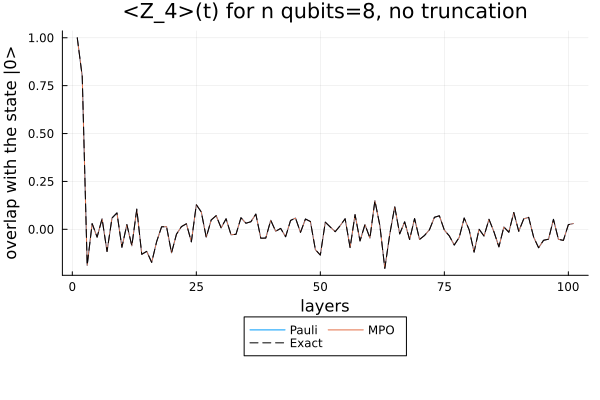

In [35]:
overlap_pp = result_pp["overlap"]
overlap_mpo = result_mpo["overlap"]
overlap_exact = result_exact["overlap"]

p = plot(title="<Z_$i>(t) for n qubits=$nqubits, no truncation", xlabel="layers", ylabel="overlap with the state |0>")

plot!(p, 1:length(overlap_pp), overlap_pp, label="Pauli")
plot!(p, 1:length(overlap_mpo), overlap_mpo, label="MPO")
plot!(p, 1:length(overlap_exact), overlap_exact, label="Exact", line = (1, :dash), color=:black)
plot!(legend=:outerbottom, legendcolumns=2)

display(p)

---

# 3. Compute complexity


In [53]:
nlayers = 100
i= 2
truncation_tolerance = 1e-2
error_tolerance = 1e-1 # for the matrix and overlap comparaison with exact result

0.1

--------------- 3=qubits ---------------
--------- Exact method propagation ---------
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by ext.propagate_layerbylayer: 0.0008189678192138672 seconds
--------- method Pauli propagation ---------
Optimal truncations find : (Max weight=3, Min abs coeff=1e-4)
layer : 10/100 complete
layer : 20/100 complete
layer : 30/100 complete
layer : 40/100 complete
layer : 50/100 complete
layer : 60/100 complete
layer : 70/100 complete
layer : 80/100 complete
layer : 90/100 complete
layer : 100/100 complete
Time taken by pp.propagate_layerbylayer: 0.10197591781616211 seconds
--------- MPO method propagation ---------
Optimal truncations find : (Maxdim=5, Cutoff=1e-4)
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer

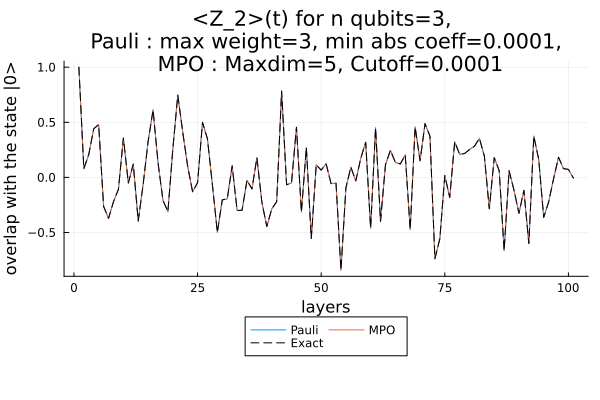

--- Matrix Errors ---
Z2(t_final) Pauli vs Exact close (tol=0.1)? true
Z2(t_final) MPO vs Exact close (tol=0.1)? false
Mean matrix error (Pauli): 3.442210142626343e-5
Mean matrix error (MPO): 0.29665987471394567

--- Overlap Curve Errors ---
Overlap Pauli vs Exact close (tol=0.1)? true
Overlap MPO vs Exact close (tol=0.1)? true
Max overlap error (Pauli): 7.17194889161693e-5
Max overlap error (MPO): 3.097522238704187e-14
--------------- 5=qubits ---------------
--------- Exact method propagation ---------
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by ext.propagate_layerbylayer: 0.02562403678894043 seconds
--------- method Pauli propagation ---------
Optimal truncations find : (Max weight=5, Min abs coeff=1e-5)
layer : 10/100 complete
layer : 20/100 complete
layer : 30/100

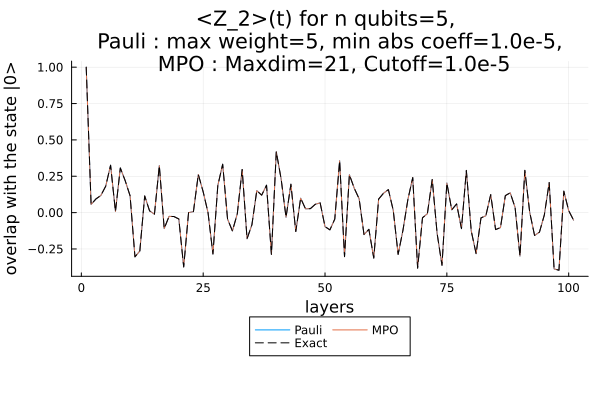

--- Matrix Errors ---
Z2(t_final) Pauli vs Exact close (tol=0.1)? true
Z2(t_final) MPO vs Exact close (tol=0.1)? false
Mean matrix error (Pauli): 8.283520888399142e-6
Mean matrix error (MPO): 0.19979604305287438

--- Overlap Curve Errors ---
Overlap Pauli vs Exact close (tol=0.1)? true
Overlap MPO vs Exact close (tol=0.1)? true
Max overlap error (Pauli): 1.755015172438812e-5
Max overlap error (MPO): 3.134992265785286e-14
--------------- 7=qubits ---------------
--------- Exact method propagation ---------
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by ext.propagate_layerbylayer: 1.6051139831542969 seconds
--------- method Pauli propagation ---------
Optimal truncations find : (Max weight=7, Min abs coeff=1e-6)
layer : 10/100 complete
layer : 20/100 complete
layer : 30/100

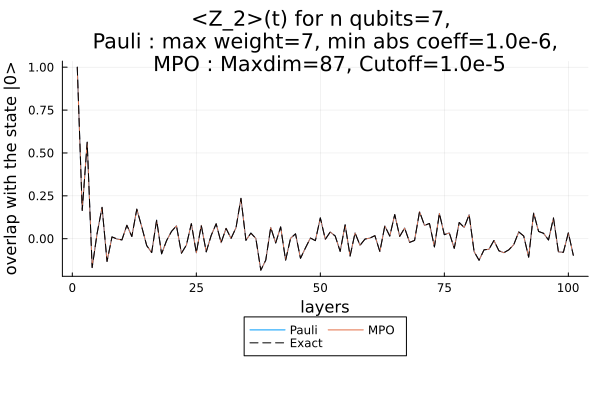

--- Matrix Errors ---
Z2(t_final) Pauli vs Exact close (tol=0.1)? true
Z2(t_final) MPO vs Exact close (tol=0.1)? true
Mean matrix error (Pauli): 1.4624525652502417e-6
Mean matrix error (MPO): 0.09993911267929817

--- Overlap Curve Errors ---
Overlap Pauli vs Exact close (tol=0.1)? true
Overlap MPO vs Exact close (tol=0.1)? true
Max overlap error (Pauli): 4.2891798004776605e-6
Max overlap error (MPO): 0.0005554142785231947
--------------- 9=qubits ---------------
--------- Exact method propagation ---------
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by ext.propagate_layerbylayer: 70.48608684539795 seconds
--------- method Pauli propagation ---------
Optimal truncations find : (Max weight=9, Min abs coeff=1e-6)
layer : 10/100 complete
layer : 20/100 complete
layer : 30/100

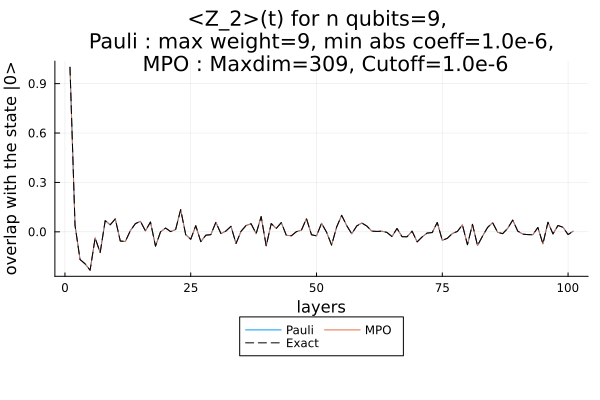

--- Matrix Errors ---
Z2(t_final) Pauli vs Exact close (tol=0.1)? true
Z2(t_final) MPO vs Exact close (tol=0.1)? true
Mean matrix error (Pauli): 6.424537628234454e-6
Mean matrix error (MPO): 0.04975774311958936

--- Overlap Curve Errors ---
Overlap Pauli vs Exact close (tol=0.1)? true
Overlap MPO vs Exact close (tol=0.1)? true
Max overlap error (Pauli): 1.5053529889492642e-5
Max overlap error (MPO): 0.00011800158244399533


In [54]:
times_exact, times_pp, times_mpo = Float64[], Float64[], Float64[]
truncations_mpo, truncations_pp = Tuple{Int64, Float64}[], Tuple{Int64, Float64}[]

Ns = 3:2:9
for nqubits in Ns
  println("--------------- $nqubits=qubits ---------------")
  circuit_pp, circuit_mpo, circuit_exact, sites = ct.random_circuit(nqubits, nlayers)

  # Exact method
  println("--------- Exact method propagation ---------")
  Z_i = ext.get_Zi(nqubits, i)
  ψ0_exact = append!([1.],[0. for _ in 2:(2^nqubits)]) # |0> state
  Zi_t_exact, result_exact = ext.propagate_layerbylayer(circuit_exact, Z_i; ψ0=ψ0_exact)
  overlap_exact = result_exact["overlap"]

  # Pauli
  println("--------- method Pauli propagation ---------")
  ## init observable
  Z_i_pauliString = PauliString(nqubits, :Z, i) # I...IZI...I

  ## test truncation
  (max_weight, min_abs_coeff) = pp.find_truncations(truncation_tolerance, circuit_pp, Z_i_pauliString, nlayers)

  ## optimal truncation application
  ψ0_pp = ψ0_exact # |0> state
  Zi_t_pauli_propagation, result_pp = pp.propagate_layerbylayer(circuit_pp, Z_i_pauliString, nlayers; max_weight, min_abs_coeff, ψ0=ψ0_pp)
  overlap_pp = result_pp["overlap"]

  ## pauli sum -> matrix
  Zi_t_pauli_propagation_matrix = pp.compute_matrix(Zi_t_pauli_propagation)

  # MPO
  println("--------- MPO method propagation ---------")
  ## init observable
  ops = ["Id" for n in 1:nqubits]
  ops[i] = "Z"
  Z_i_mpo = MPO(sites, ops)
  dim = 2^nqubits

  ## test truncation
  (maxdim, cutoff) = mpo.find_truncations(truncation_tolerance, circuit_mpo, Z_i_mpo)

  ## optimal truncation application
  ψ0_mps = MPS(sites, "0") # |↑↑..↑>
  Zi_t_mpo, result_mpo = mpo.propagate_layerbylayer(circuit_mpo, Z_i_mpo; cutoff, maxdim, ψ0=ψ0_mps)
  overlap_mpo = result_mpo["overlap"]

  ## Itensor -> matrix
  Zi_t_mpo_matrix = mpo.compute_matrix(Zi_t_mpo, sites)

  # plot to see if its good
  println("--------- Plot & Result ---------")
  us.overlap_with_Zi_plot(nqubits, overlap_pp, overlap_mpo, overlap_exact, i, max_weight, min_abs_coeff, maxdim, cutoff)
  us.print_methods_error(Zi_t_exact, Zi_t_pauli_propagation_matrix, Zi_t_mpo_matrix, overlap_exact, overlap_pp, overlap_mpo, error_tolerance; operatorName="Z$i")

  # push the time of propagation to see complexity
  push!(truncations_pp, (max_weight, min_abs_coeff))
  push!(truncations_mpo, (maxdim, cutoff))
  push!(times_exact, result_exact["time"])
  push!(times_pp, result_pp["time"])
  push!(times_mpo, result_mpo["time"])
end


In [60]:
println(typeof(Ns))

StepRange{Int64, Int64}


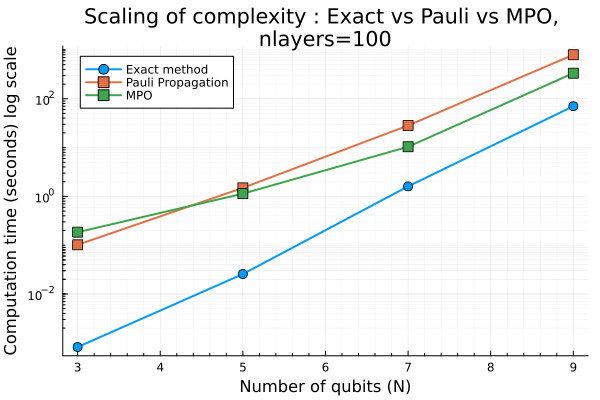

In [62]:
us.complexity_plot(Ns, nlayers, times_exact, times_pp, times_mpo; logscale=true)

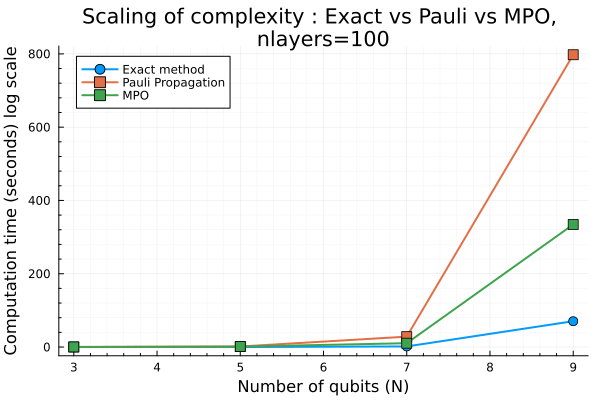

In [63]:
us.complexity_plot(Ns, nlayers, times_exact, times_pp, times_mpo)

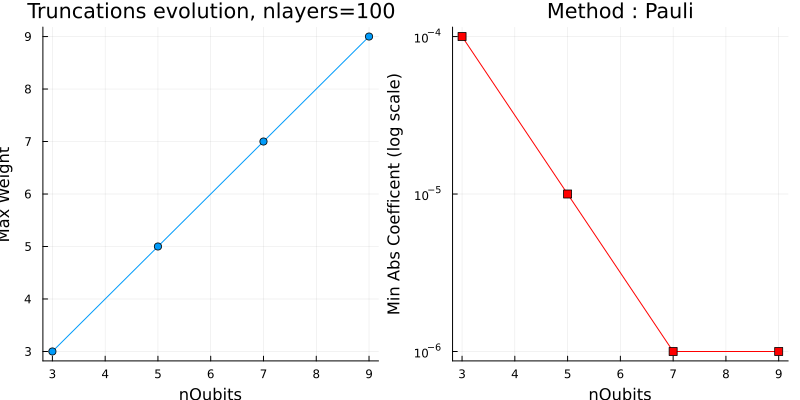

In [66]:
us.truncation_plot(Ns, truncations_pp; method="Pauli", title="Truncations evolution, nlayers=$nlayers", parameterName="nQubits")

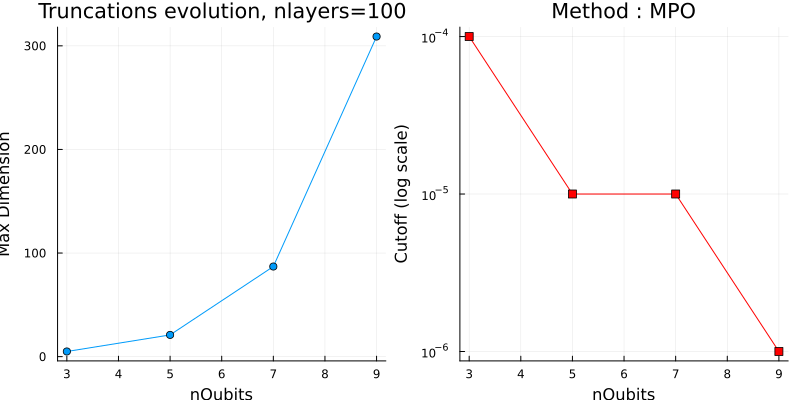

In [65]:
us.truncation_plot(Ns, truncations_mpo; method="MPO", title="Truncations evolution, nlayers=$nlayers", parameterName="nQubits")

### Pauli Prop observation

For a maximum weight below the number of Qubits, our method troncate $c_\alpha$ wich are important for the physical state.

This seems consistent with the type of circuit through which we propagate our observable.
Indeed, a circuit composed of random gates creates a lot of correlation between the qubits. Consequently, a max weight that is too small avoids strong correlations and thus takes us drastically away from the exact physical state, which is highly correlated.

"complex quantum dynamics may generate a considerable number of new Pauli strings – exponential in the number of non-Clifford gates – each with a small coefficien"

---

# 5. Thermalisation

In [85]:
therm_layer = nlayers ÷ 4 # we let 25% of the circuit for the system to be thermalized

25

In [86]:
overlap_result_average_pp = mean(overlap_pp[therm_layer:end])
println(overlap_result_average_pp)

0.0030765459217746076


In [87]:
overlap_result_average_mpo = mean(overlap_mpo[therm_layer:end])
println(overlap_result_average_mpo)

0.003084674761513004


---

## References

### Paper
- [Random Circuit](https://arxiv.org/abs/2603.20400)
- [Pauli Propagation](https://arxiv.org/abs/2505.21606)
- [Haar Random Matrix](https://arxiv.org/abs/math-ph/0609050)
- [Operator Entanglement](https://www.phys.ens.psl.eu/~jacobsen/AMP21_Dubail.pdf)

### Julia Package
- [Julia documentation](https://docs.julialang.org/en/v1/)
- [PauliPropagation.jl](https://github.com/MSRudolph/PauliPropagation.jl)
- [ITensor documentation](https://docs.itensor.org/ITensors/stable/index.html)
- [Plots documentation](https://docs.juliaplots.org/stable/)
- [LinearAlgebra documentation](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/)
- [LaTeXStrings documentation](https://juliapackages.com/p/latexstrings)

### Other
- Latex Tiks documentation https://www.overleaf.com/learn/latex/LaTeX_Graphics_using_TikZ%3A_A_Tutorial_for_Beginners_(Part_3)%E2%80%94Creating_Flowcharts